
**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

medical_df = pd.read_csv('sample_data/medical-charges.csv')

medical_df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


1. Дослідити вік - чим старша людина, тим вищі ризики захворювань, отже витрати будуть зростати.
2. Статус курця: куріння підвищує ризик серйозних хвороб. Можна припустити, що для курців витрати будуть вищі.
3. BMI. Високий BMI може вказувати на проблеми з вагою, що тягне за собою додаткові витрати.

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [3]:
fig = px.histogram(medical_df,
                   x='charges',
                   color='sex',
                   marginal='box',
                   title='Розподіл за статтю',
                   nbins=50)
fig.update_layout(bargap=0.1)
fig.show()

fig2 = px.histogram(medical_df,
                   x='charges',
                   color='region',
                   marginal='box',
                   title='Розподіл за регіоном',
                   nbins=50)
fig2.update_layout(bargap=0.1)
fig2.show()

Розподіли для чоловіків та жінок дуже схожі, але у чоловіків трохи більший правий хвіст (більші витрати). Щодо регіонів, то виділяється southeast, де витрати можуть бути трохи вищими (теж правий хвіст).

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [6]:
fig3 = px.histogram(medical_df,
                    x='region',
                    color='smoker',
                    barmode='group',
                    title='Кількість курців за регіонами')
fig3.show()

fig4 = px.histogram(medical_df,
                    x='children',
                    color='smoker',
                    barmode='group',
                    title='Кількість курців в залежності від кількості дітей')
fig4.show()

У регіоні southeast кількість курців візуально більша, ніж в інших. Це мабуть пояснює, чому середні витрати там вищі щодо попреденього висновку.
Чим більше дітей у родині, тим менше курців

**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [7]:
fig5 = px.violin(medical_df,
                 x='children',
                 y='charges',
                 box=True,
                 points='all',
                 title='Залежність витрат від кількості дітей')
fig5.show()

Медіанні витрати можуть дещо зростати для сімей з 2-3 дітьми, але для 5 дітей вони можуть бути нижчими (можливо, через малу вибірку?). Також є викиди для кожної категорі

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [8]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [9]:
def estimate_charges(age, w, b):
    return w * age + b

In [10]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

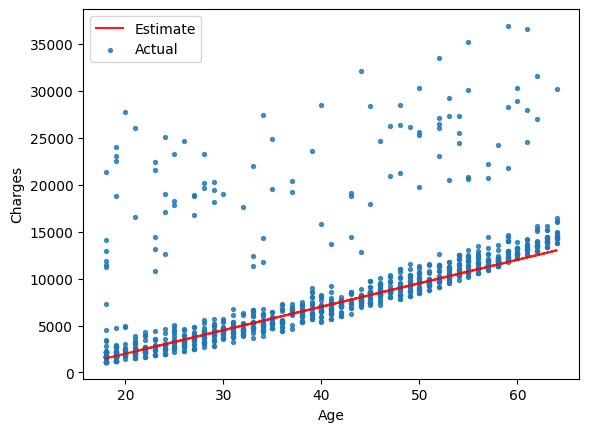

In [21]:
w1, b1 = 250, -3000
try_parameters(non_smoker_df, w1, b1)

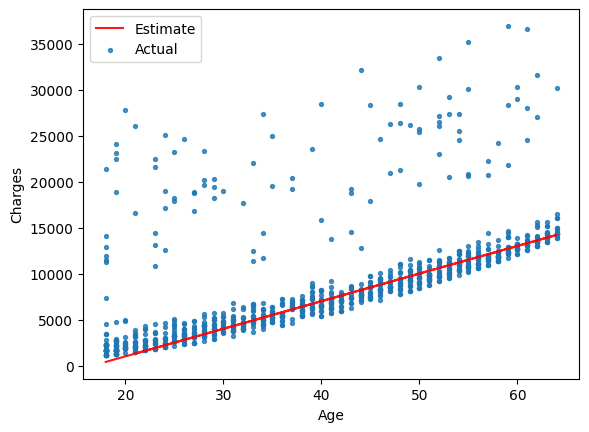

In [22]:
w2, b2 = 300, -5000
try_parameters(non_smoker_df, w2, b2)

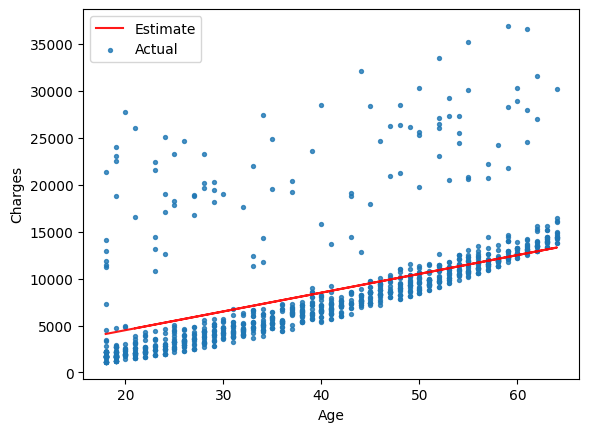

In [23]:
w3, b3 = 200, 500
try_parameters(non_smoker_df, w3, b3)

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [27]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

ages = non_smoker_df.age
targets = non_smoker_df.charges

# Для пари 250, -3000
pred1 = estimate_charges(ages, w1, b1)
print(f"RMSE (w={w1}, b={b1}): {rmse(targets, pred1)}")

# Для пари300, -5000
pred2 = estimate_charges(ages, w2, b2)
print(f"RMSE (w={w2}, b={b2}): {rmse(targets, pred2)}")

# Для пари 200, 500
pred3 = estimate_charges(ages, w3, b3)
print(f"RMSE (w={w3}, b={b3}): {rmse(targets, pred3)}")

RMSE (w=250, b=-3000): 4931.47542485992
RMSE (w=300, b=-5000): 4956.973980899423
RMSE (w=200, b=500): 4757.980240770584


Параметри w=200 і b=500 виглядають найкращими бо в середньому помилка найнижча